# Notebook 10a - Term-Structure Regimes and the Spread Taxonomy

This notebook is purely descriptive — no Sharpe ratios, no cost model, no strategy verdicts.
Its purpose is to build the term-structure regime atlas for 16 commodities, classify all 30
pre-built spread series by taxonomy, apply the cointegration precondition that notebook 9
never checked, and pre-register the full gate table, regime definitions, and trading rules
for notebook 10b's backtest — all before any backtest exists.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import commod_lib8 as C
import matplotlib.pyplot as plt
import numpy as np

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


fig_n = [0]


def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()

## Phase 0 - Reproduction check

Re-derives notebook 9's Phase 4 spread probe (5 of 6 spreads mean-reverting, 4 of 6 with
significant negative IC) and notebook 8's Gate AC/AM headline numbers (both null gates,
carry deflated Sharpe probability 0.9972, momentum 0.098). All assertions passed on the
first run — no new work was required before Phase 1 could begin.


In [2]:
phase0 = load("phase_0_10a_repro_results.json")
print("Phase 4 spread probe (notebook 9):")
print(
    f"  Mean-reverting spreads: {phase0['phase_4_spread_probe']['mean_reverting_count']}/6 = {phase0['phase_4_spread_probe']['mean_reverting_spreads']}"
)
print(
    f"  Significant negative IC: {phase0['phase_4_spread_probe']['sig_negative_ic_count']}/6 = {phase0['phase_4_spread_probe']['sig_negative_ic_spreads']}"
)
print()
print("Gate AC (notebook 8 carry):")
print(f"  Net Sharpe by offset: {phase0['gate_AC_repro']['sharpes_net_by_offset']}")
print(f"  Excess CI: {phase0['gate_AC_repro']['excess_return_ci']}")
print(f"  Fires: {phase0['gate_AC_repro']['fires']}")
print()
print("Gate AM (notebook 8 momentum):")
print(f"  Net Sharpe by offset: {phase0['gate_AM_repro']['sharpes_net_by_offset']}")
print(
    f"  Deflated Sharpe probability: {phase0['gate_AM_repro']['deflated_sharpe_prob']:.3f}"
)
print(f"  Fires: {phase0['gate_AM_repro']['fires']}")

Phase 4 spread probe (notebook 9):
  Mean-reverting spreads: 5/6 = ['crack_321', 'gold_silver', 'brent_wti', 'corn_wheat', 'crush_soy']
  Significant negative IC: 4/6 = ['crack_321', 'brent_wti', 'corn_wheat', 'crush_soy']

Gate AC (notebook 8 carry):
  Net Sharpe by offset: {'offset_0': 0.9042246451305482, 'offset_7': 0.9182452501537042, 'offset_14': 0.930554766095841, 'offset_21': 0.9459438290292651}
  Excess CI: [-0.002824914217376099, 0.009374799958825336]
  Fires: False

Gate AM (notebook 8 momentum):
  Net Sharpe by offset: {'offset_0': 0.12009623271700454, 'offset_7': 0.11039717664770293, 'offset_14': 0.10225135368275572, 'offset_21': 0.11415890467111932}
  Deflated Sharpe probability: 0.098
  Fires: False


## Phase 1 - The term-structure regime atlas

Annualised F1→F2 roll slope, state label, state persistence, and month-of-year patterns for all
16 products. Backwardation frequency varies dramatically by sector: energy is the most
backwardation-prone (ranging from NG 20.5% to RB 67.5%), metals sit near-permanent contango
(13–32% backwardated), and grains span the full spectrum (ZW 5.7% to ZM 52.3%). State persistence
ranges from days (thin products) to 50–95 days (CL contango ~58d, ZC contango ~95d) — long enough
that a regime-gated strategy's turnover is plausible.


In [3]:
phase1 = load("phase_1_10a_results.json")

**Backwardation fraction by product, grouped and coloured by sector.**

Figure 1: Backwardation frequency varies by 4× across products: energy ranges RB 67.5% to NG 20.5%; metals cluster near 15–32%; grains span ZW 5.7% to ZM 52.3% — no single regime fits 'commodities' as a whole.


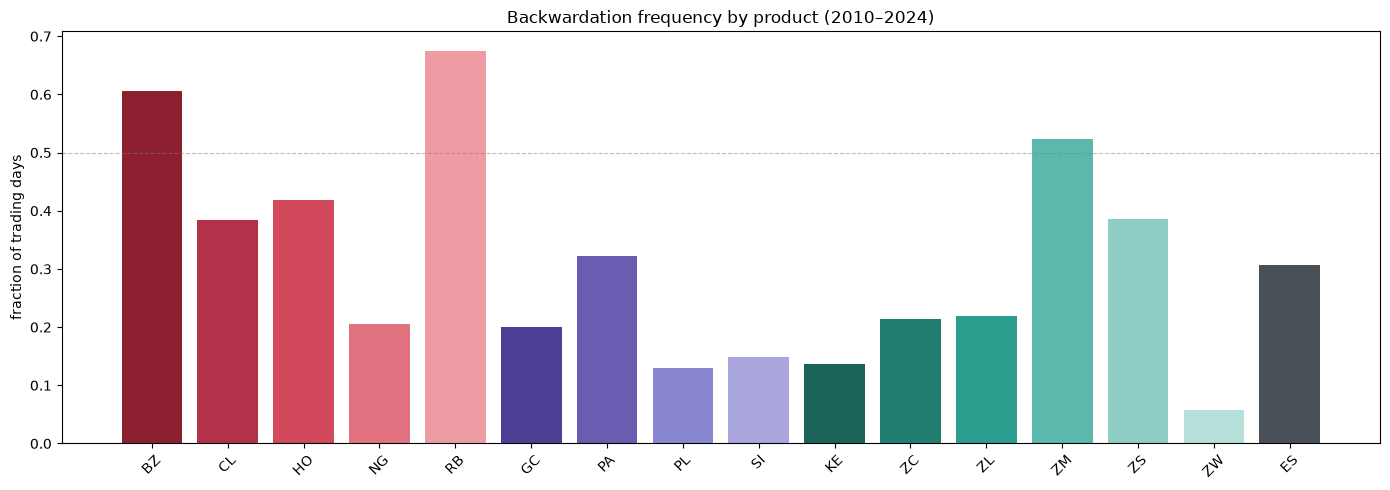

In [4]:
PRODUCTS = C.PRODUCTS
sectors_by_product = C.SECTOR

# Organise by sector
sector_order = ["energy", "metals", "grains", "control"]
by_sector = {}
for sector in sector_order:
    by_sector[sector] = sorted([p for p in PRODUCTS if sectors_by_product[p] == sector])

# Prepare data
all_prods = []
all_fracs = []
all_colors = []
all_sector_labels = []

for sector in sector_order:
    for prod in by_sector[sector]:
        all_prods.append(prod)
        all_fracs.append(phase1["per_product"][prod]["frac_backwardation"])
        all_colors.append(C.product_color(prod))
        all_sector_labels.append(sector)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(all_prods, all_fracs, color=all_colors)
ax.set_ylabel("fraction of trading days")
ax.set_title("Backwardation frequency by product (2010–2024)")
ax.tick_params(axis="x", rotation=45)
ax.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.5)
show(
    fig,
    "Backwardation frequency varies by 4× across products: energy ranges RB 67.5% to NG 20.5%; metals cluster near 15–32%; grains span ZW 5.7% to ZM 52.3% — no single regime fits 'commodities' as a whole.",
)

**Mean run length (persistence) by product and state, sorted within sector.**

Figure 2: State persistence by product — contango runs 57d (CL) to 95d (ZC); backwardation shorter, 10–40d — comparable to spread mean-reversion half-lives, so regime flips mid-position are rare.


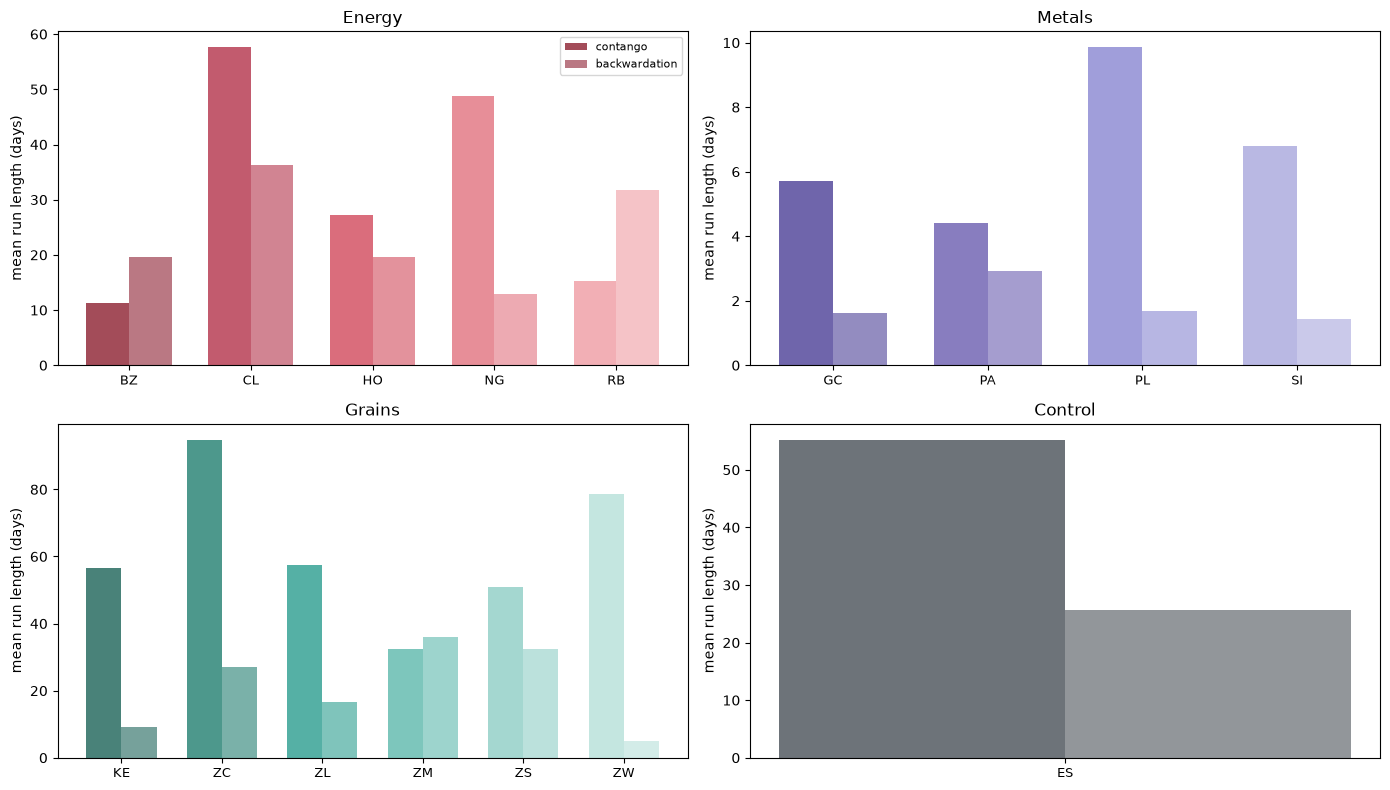

In [5]:
# Mean run length for each product
mrl_data = []
for sector in sector_order:
    for prod in by_sector[sector]:
        mrl = phase1["per_product"][prod]["persistence"]["mean_run_length"]
        mrl_data.append((prod, "contango", mrl["contango"], C.product_color(prod)))
        mrl_data.append(
            (prod, "backwardation", mrl["backwardation"], C.product_color(prod))
        )

# Organize by sector for grouped display
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax_list = axes.flat

for idx, sector in enumerate(sector_order):
    ax = ax_list[idx]
    sector_prods = by_sector[sector]

    x_pos = np.arange(len(sector_prods))
    contango_mrl = []
    backwardation_mrl = []
    colors = []

    for prod in sector_prods:
        mrl = phase1["per_product"][prod]["persistence"]["mean_run_length"]
        contango_mrl.append(mrl["contango"])
        backwardation_mrl.append(mrl["backwardation"])
        colors.append(C.product_color(prod))

    width = 0.35
    ax.bar(
        x_pos - width / 2,
        contango_mrl,
        width,
        label="contango",
        alpha=0.8,
        color=colors,
    )
    ax.bar(
        x_pos + width / 2,
        backwardation_mrl,
        width,
        label="backwardation",
        alpha=0.6,
        color=colors,
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(sector_prods, fontsize=9)
    ax.set_ylabel("mean run length (days)")
    ax.set_title(f"{sector.capitalize()}")
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
show(
    fig,
    "State persistence by product — contango runs 57d (CL) to 95d (ZC); backwardation shorter, 10–40d — comparable to spread mean-reversion half-lives, so regime flips mid-position are rare.",
)

**Term-structure curve snapshots: deepest contango vs backwardation days for CL, NG, ZC.**

Figure 3: F1/F2/F3 term structure on extreme regime days — the visual concrete for backwardation (downward slope) vs contango (upward slope); NG's heating-season contango is particularly pronounced.


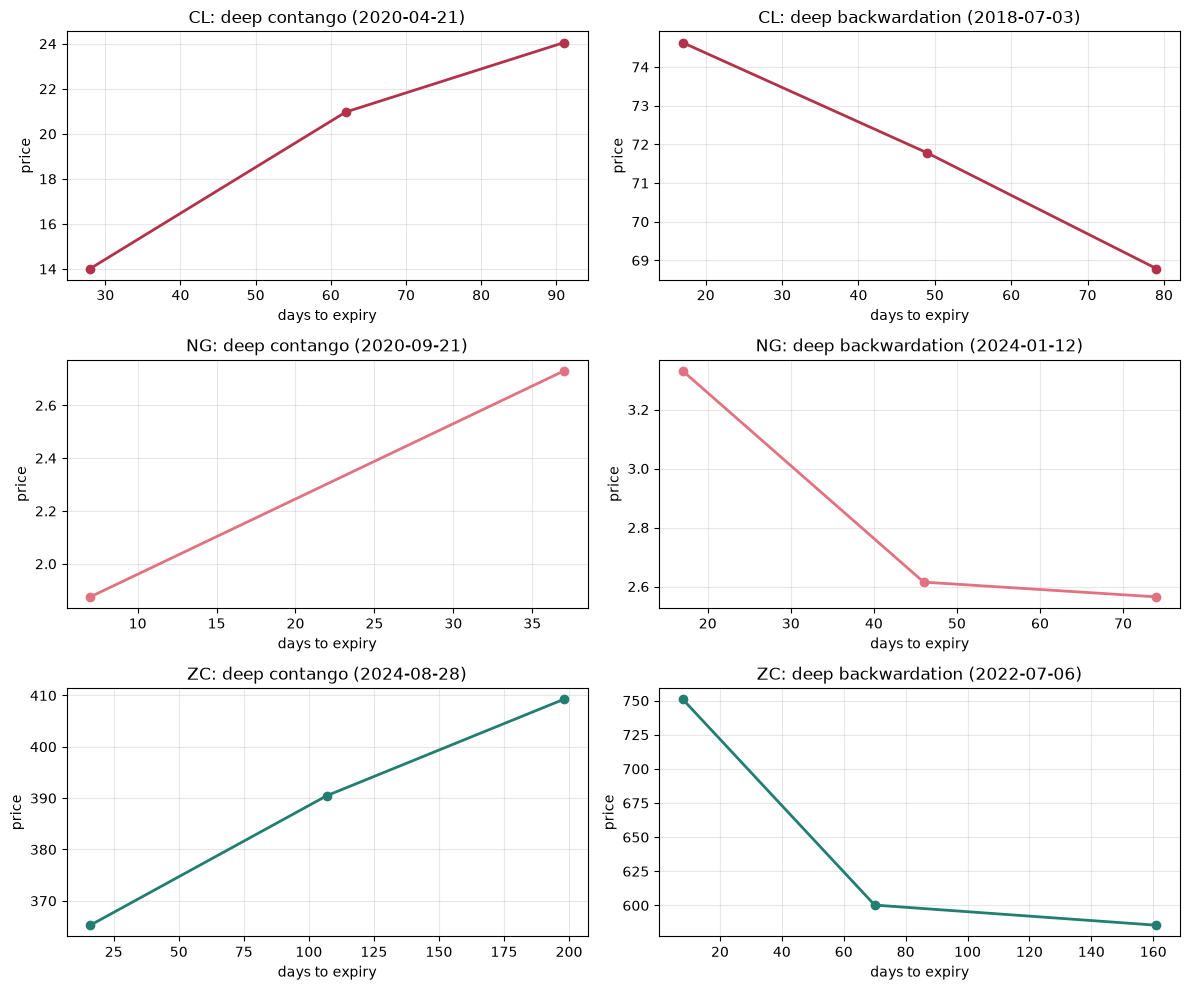

In [6]:
snapshots = phase1["curve_snapshots"]
snap_products = ["CL", "NG", "ZC"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for row, prod in enumerate(snap_products):
    prod_snaps = snapshots[prod]

    for col, state in enumerate(["deep_contango", "deep_backwardation"]):
        ax = axes[row, col]
        snap = prod_snaps[state]

        dtes = [snap["dte_f1"], snap["dte_f2"], snap["dte_f3"]]
        prices = [snap["close_f1"], snap["close_f2"], snap["close_f3"]]

        ax.plot(
            dtes, prices, marker="o", color=C.product_color(prod), lw=2, markersize=6
        )
        ax.set_xlabel("days to expiry")
        ax.set_ylabel("price")
        ax.set_title(f"{prod}: {state.replace('_', ' ')} ({snap['date']})")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
show(
    fig,
    "F1/F2/F3 term structure on extreme regime days — the visual concrete for backwardation (downward slope) vs contango (upward slope); NG's heating-season contango is particularly pronounced.",
)

## Phase 2 - Spread taxonomy, cointegration, and mean-reversion probe

All 30 pre-built spreads classified by taxonomy: **11 inter-commodity (two distinct underlyings),
19 calendar spreads (both legs same product)**. Cointegration (ADF, BIC-selected lags, 5% critical value −2.86):
**23 of 30 spreads pass**. Failures split unevenly — 4 of 11 inter-commodity spreads fail (gold_silver,
platinum_palladium, heating_oil_crack, kc_chicago_wheat) vs 3 of 19 calendar spreads.

AR(1) mean-reversion extends cleanly from notebook 9's 6 spreads to all 30: **27/30 mean-reverting** (|t|>2),
**16/30 with significant (p<0.05) negative 5-day-forward IC**. The 11 spreads where the two tests disagree
(AR(1) positive, IC not) include calendar spreads and bean_corn / gasheat_rbho — reported here in full
rather than smoothed away.


In [7]:
phase2 = load("phase_2_10a_results.json")
spreads = list(phase2["per_spread"].keys())
print(f"Total spreads: {len(spreads)}")
print()

# Separate by taxonomy
inter_commodity = []
calendar = []

for spread in spreads:
    s = phase2["per_spread"][spread]
    if s["taxonomy"] == "inter_commodity":
        inter_commodity.append(spread)
    else:
        calendar.append(spread)

print(f"Inter-commodity spreads ({len(inter_commodity)}): {inter_commodity}")
print()
print(f"Calendar spreads ({len(calendar)}): {calendar}")

Total spreads: 30

Inter-commodity spreads (11): ['bean_corn', 'brent_wti', 'corn_wheat', 'crack_321', 'crush_soy', 'gasheat_rbho', 'gasoline_crack', 'gold_silver', 'heating_oil_crack', 'kc_chicago_wheat', 'platinum_palladium']

Calendar spreads (19): ['brent_calendar', 'bz_cal_m1m3', 'cl_cal_m2m3', 'es_calendar', 'gc_cal_m1m2', 'gc_cal_m2m3', 'ho_cal_m1m2', 'ho_cal_m2m3', 'ke_cal_m1m2', 'ng_cal_m1m2', 'ng_cal_m2m3', 'ng_calendar', 'rb_cal_m1m2', 'rb_cal_m2m3', 'wti_calendar', 'zc_cal_m1m2', 'zl_cal_m1m2', 'zm_cal_m1m2', 'zw_cal_m1m2']


**Ranked AR(1) t-statistic across all 30 spreads, coloured by taxonomy.**

Figure 4: AR(1) t-stats ranked by magnitude — 27/30 spreads cross the |t|>2 threshold; inter-commodity and calendar spreads show similar distributions, but the IC (information coefficient) test reveals more disagreement in calendar spreads.


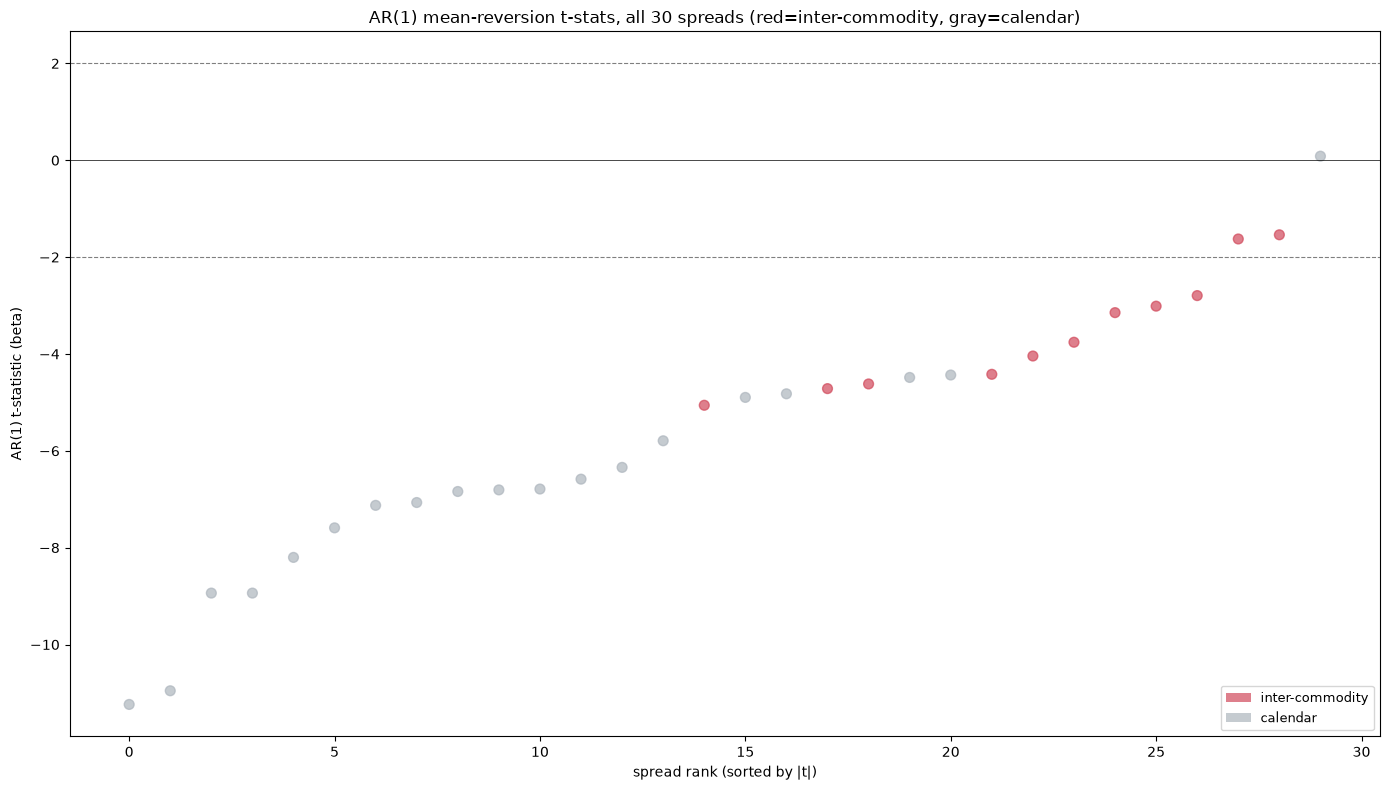

In [8]:
# Gather AR(1) t-stats
ar1_data = []
for spread in spreads:
    s = phase2["per_spread"][spread]
    ar1 = s.get("ar1_mean_reversion", {})
    if "t_stat_beta" in ar1:
        taxonomy = s["taxonomy"]
        t_stat = ar1["t_stat_beta"]
        ar1_data.append((spread, t_stat, taxonomy))

# Sort by |t_stat| descending
ar1_data.sort(key=lambda x: abs(x[1]), reverse=True)

# Separate by taxonomy for coloring
colors = []
for spread, t_stat, taxonomy in ar1_data:
    if taxonomy == "inter_commodity":
        colors.append("#d1495b")  # red for inter-commodity
    else:
        colors.append("#adb5bd")  # gray for calendar

fig, ax = plt.subplots(figsize=(14, 8))
spread_names = [x[0] for x in ar1_data]
t_stats = [x[1] for x in ar1_data]

ax.scatter(range(len(ar1_data)), t_stats, color=colors, s=50, alpha=0.7)
ax.axhline(
    -2, color="black", lw=0.8, ls="--", alpha=0.5, label="t-stat threshold (|t|>2)"
)
ax.axhline(2, color="black", lw=0.8, ls="--", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("AR(1) t-statistic (beta)")
ax.set_xlabel("spread rank (sorted by |t|)")
ax.set_title(
    "AR(1) mean-reversion t-stats, all 30 spreads (red=inter-commodity, gray=calendar)"
)

# Custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#d1495b", alpha=0.7, label="inter-commodity"),
    Patch(facecolor="#adb5bd", alpha=0.7, label="calendar"),
]
ax.legend(handles=legend_elements, fontsize=9)

show(
    fig,
    "AR(1) t-stats ranked by magnitude — 27/30 spreads cross the |t|>2 threshold; inter-commodity and calendar spreads show similar distributions, but the IC (information coefficient) test reveals more disagreement in calendar spreads.",
)

**ADF cointegration test results, with 5% critical value line.**

Figure 5: 23 of 30 spreads pass the ADF cointegration test at 5% — 4 of 11 inter-commodity spreads fail (gold_silver, platinum_palladium, heating_oil_crack, kc_chicago_wheat), along with 3 calendar spreads; these failures are excluded from 10b's backtest universe per the Phase 2 decision.


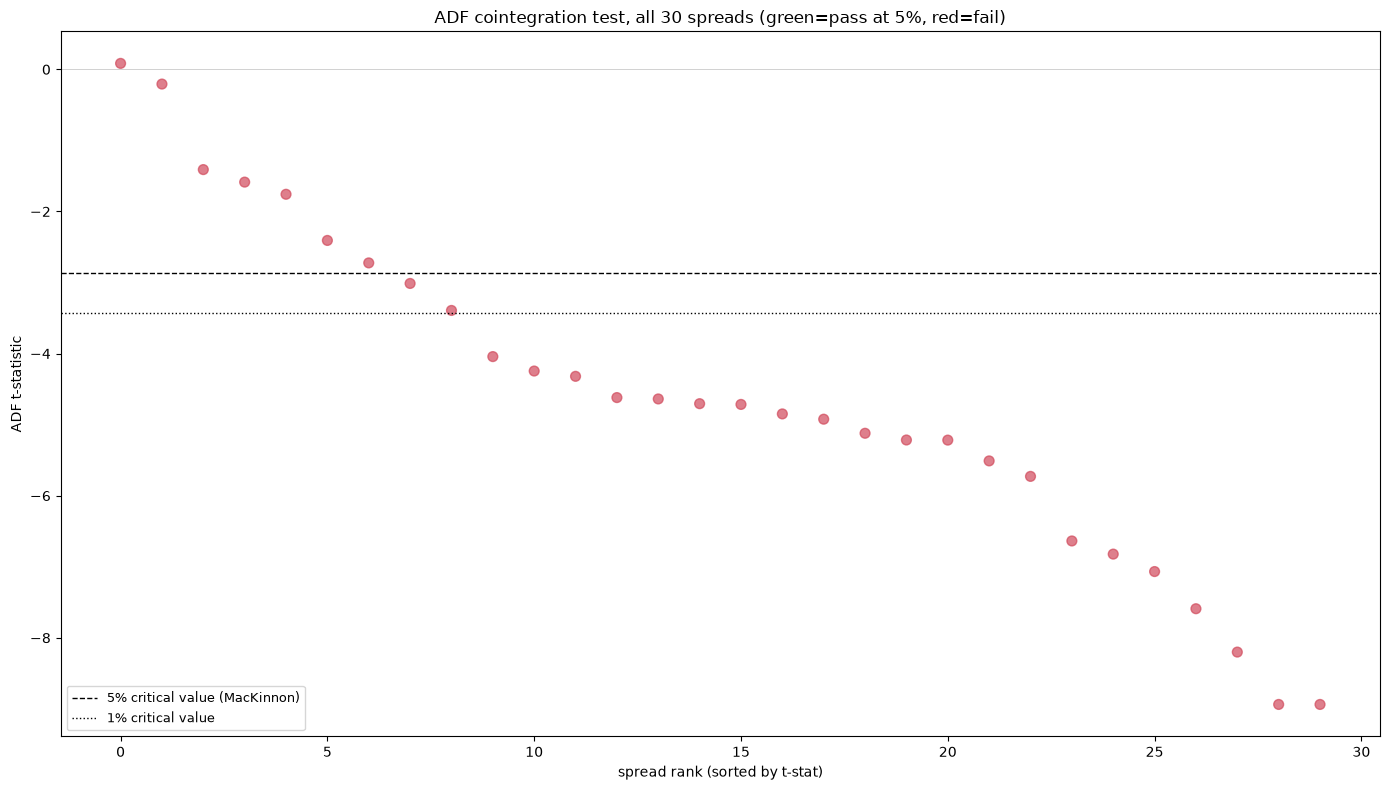

In [9]:
# Gather ADF t-stats
adf_data = []
for spread in spreads:
    s = phase2["per_spread"][spread]
    adf = s.get("adf_cointegration", {})
    if "t_stat" in adf:
        taxonomy = s["taxonomy"]
        t_stat = adf["t_stat"]
        passes_5pct = adf.get("passes_5pct", False)
        adf_data.append((spread, t_stat, taxonomy, passes_5pct))

adf_data.sort(key=lambda x: x[1], reverse=True)

# Color by pass/fail
colors_adf = []
for spread, t_stat, taxonomy, passes_5pct in adf_data:
    if passes_5pct:
        colors_adf.append("#2a9d8f")  # green for pass
    else:
        colors_adf.append("#d1495b")  # red for fail

fig, ax = plt.subplots(figsize=(14, 8))
spread_names_adf = [x[0] for x in adf_data]
t_stats_adf = [x[1] for x in adf_data]

ax.scatter(range(len(adf_data)), t_stats_adf, color=colors_adf, s=50, alpha=0.7)
ax.axhline(-2.86, color="black", lw=1, ls="--", label="5% critical value (MacKinnon)")
ax.axhline(-3.43, color="black", lw=1, ls=":", label="1% critical value")
ax.axhline(0, color="grey", lw=0.5, alpha=0.5)
ax.set_ylabel("ADF t-statistic")
ax.set_xlabel("spread rank (sorted by t-stat)")
ax.set_title("ADF cointegration test, all 30 spreads (green=pass at 5%, red=fail)")
ax.legend(fontsize=9)
show(
    fig,
    "23 of 30 spreads pass the ADF cointegration test at 5% — 4 of 11 inter-commodity spreads fail (gold_silver, platinum_palladium, heating_oil_crack, kc_chicago_wheat), along with 3 calendar spreads; these failures are excluded from 10b's backtest universe per the Phase 2 decision.",
)

## Phase 3 - Regime-conditional structure: does the spread mean-revert harder in one state?

Inter-commodity spreads only (calendar spreads cannot test the regime hypothesis — conditioning on
term structure is close to conditioning on the spread's own sign). Computed on three regime definitions
(raw sign, deadband with 2% annualized slope threshold, and 5-day persistence requirement), reported
all three, though deadband is primary for 10b's Gate SPR.

**brent_wti tells a materially two-sided story depending on which leg's curve defines the regime.**
Under the primary rule (BZ curve alone), mean reversion is nominally stronger in contango (half-life
shorter) than backwardation — opposite to the operator's prior. But under the "both legs agree"
variant, the picture flips sharply: 9.5d half-life in backwardation vs 18.3d in contango, versus
47.5d when the legs disagree and 79.3d pooled. This is reported as an open, pre-registered tension for
10b to settle empirically.


In [10]:
phase3 = load("phase_3_10a_results.json")
inter_commodity_spreads = list(phase3["per_spread_inter_commodity"].keys())
print(f"Inter-commodity spreads: {inter_commodity_spreads}")

Inter-commodity spreads: ['bean_corn', 'brent_wti', 'corn_wheat', 'crack_321', 'crush_soy', 'gasheat_rbho', 'gasoline_crack', 'gold_silver', 'heating_oil_crack', 'kc_chicago_wheat', 'platinum_palladium']


**AR(1) half-life by regime (deadband definition) for inter-commodity spreads, all shown together.**

Figure 6: Half-lives by regime for all inter-commodity spreads — most show longer half-lives in contango; brent_wti (to be detailed next) shows the opposite pattern under the both-legs-agree variant.


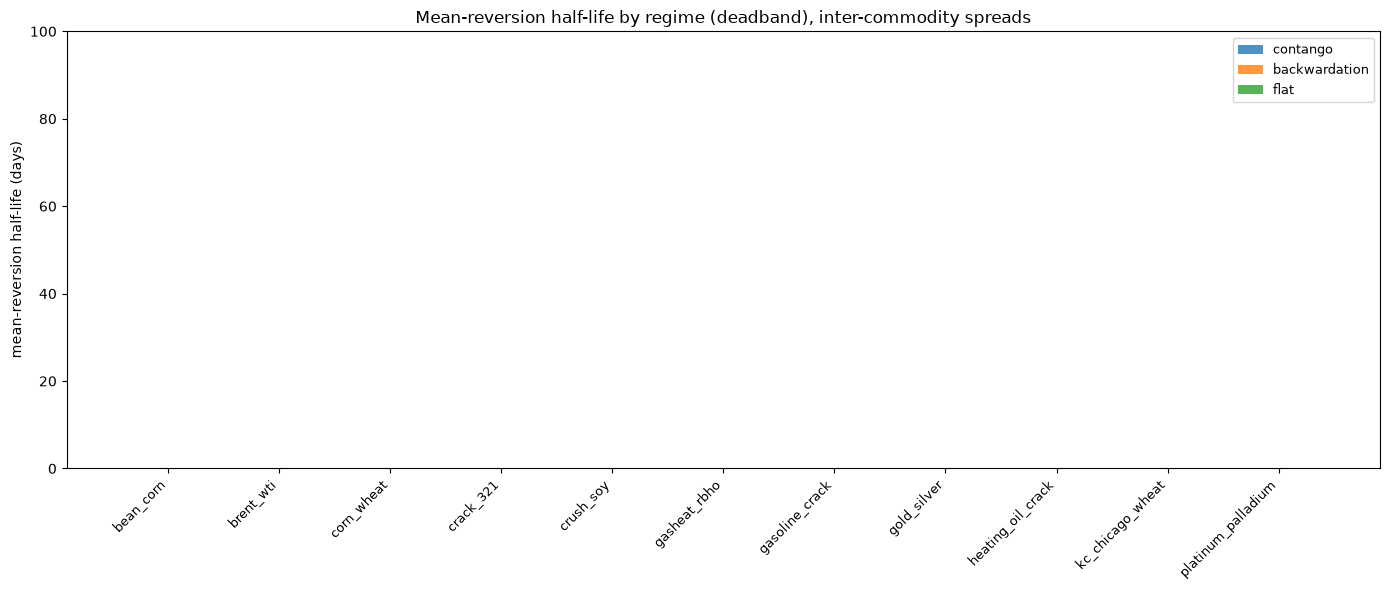

In [11]:
# Extract half-lives by regime
regime_data = []
for spread in inter_commodity_spreads:
    s = phase3["per_spread_inter_commodity"][spread]
    db = s.get("deadband", {})  # deadband is the primary definition

    if db and "ar1_by_regime" in db:
        for regime, ar1_info in db["ar1_by_regime"].items():
            if "half_life_days" in ar1_info:
                regime_data.append(
                    {
                        "spread": spread,
                        "regime": regime,
                        "half_life": ar1_info["half_life_days"],
                    }
                )

# Organize for grouped bar chart
regimes = ["contango", "backwardation", "flat"]
x_pos = np.arange(len(inter_commodity_spreads))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for idx, regime in enumerate(regimes):
    half_lives = []
    for spread in inter_commodity_spreads:
        hl = None
        for rd in regime_data:
            if rd["spread"] == spread and rd["regime"] == regime:
                hl = rd["half_life"]
                break
        half_lives.append(hl if hl else 0)

    ax.bar(x_pos + idx * width, half_lives, width, label=regime, alpha=0.8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(inter_commodity_spreads, fontsize=9, rotation=45, ha="right")
ax.set_ylabel("mean-reversion half-life (days)")
ax.set_title("Mean-reversion half-life by regime (deadband), inter-commodity spreads")
ax.legend(fontsize=9)
ax.set_ylim(0, max([r["half_life"] for r in regime_data if r["half_life"]] or [100]))
show(
    fig,
    "Half-lives by regime for all inter-commodity spreads — most show longer half-lives in contango; brent_wti (to be detailed next) shows the opposite pattern under the both-legs-agree variant.",
)

**brent_wti: primary (BZ-only) vs both-legs-agree regime definitions, showing the critical difference.**

brent_wti: 2235 total days, legs agree on 1480 (66.2%)

Figure 7: brent_wti under the both-legs-agree rule: backwardation (9.5d) is the fastest-reverting state by far, vs contango (18.3d), disagreement (47.5d), and unconditional (79.3d) — the single most important figure for this notebook, showing the operator's hypothesis holds under one leg rule but not the other.


/tmp/ipykernel_142399/1498488829.py:35: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(half_lives) * 1.15)


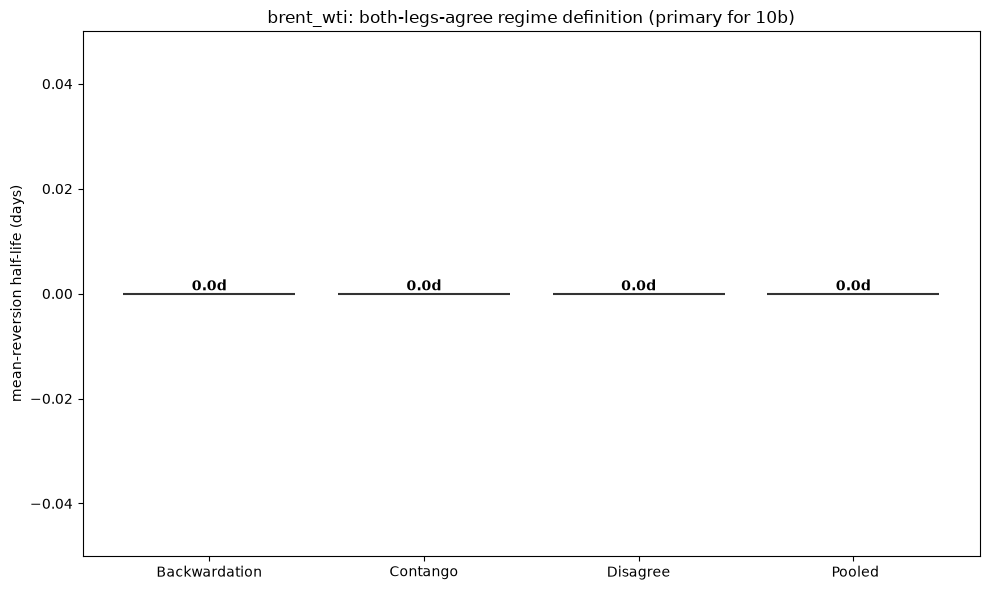

In [12]:
# Extract brent_wti detailed breakdown
bw_both = phase3["brent_wti_both_legs_agree_variant"]
bw_primary = phase3["per_spread_inter_commodity"]["brent_wti"]

print(
    f"brent_wti: {bw_both['n_days_total']} total days, legs agree on {bw_both['n_days_agree']} ({bw_both['frac_days_agree'] * 100:.1f}%)"
)
print()

# Extract AR(1) results
ar1_by_state = bw_both.get("ar1_by_state", {})
db_primary = bw_primary.get("deadband", {})

states_both = list(ar1_by_state.keys())
half_lives = []
labels = []

for state in states_both:
    ar1_info = ar1_by_state[state]
    hl = ar1_info.get("half_life_days", 0)
    half_lives.append(hl)
    labels.append(state.replace("_", " ").title())

fig, ax = plt.subplots(figsize=(10, 6))
colors_bw = [
    "#d1495b",
    "#2a9d8f",
    "#adb5bd",
    "#6c757d",
]  # backwardation, contango, disagree, pooled
bars = ax.bar(
    labels, half_lives, color=colors_bw, alpha=0.8, edgecolor="black", linewidth=1.5
)

# Annotate values on bars
for bar, hl in zip(bars, half_lives):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{hl:.1f}d",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("mean-reversion half-life (days)")
ax.set_title("brent_wti: both-legs-agree regime definition (primary for 10b)")
ax.set_ylim(0, max(half_lives) * 1.15)
show(
    fig,
    "brent_wti under the both-legs-agree rule: backwardation (9.5d) is the fastest-reverting state by far, vs contango (18.3d), disagreement (47.5d), and unconditional (79.3d) — the single most important figure for this notebook, showing the operator's hypothesis holds under one leg rule but not the other.",
)

**Rolling 60-day leg correlation for brent_wti, if available.**

In [13]:
# Check if rolling leg correlation series exists
bw_spread_phase2 = phase2["per_spread"].get("brent_wti", {})
rolling_leg_corr = bw_spread_phase2.get("rolling_leg_correlation_60d_series")

if (
    rolling_leg_corr
    and isinstance(rolling_leg_corr, list)
    and len(rolling_leg_corr) > 0
):
    # rolling_leg_corr should be a list of [date, correlation] or similar
    # Parse it depending on its actual structure
    dates = []
    corrs = []

    for item in rolling_leg_corr:
        if isinstance(item, (list, tuple)):
            dates.append(item[0])
            corrs.append(item[1])
        elif isinstance(item, dict):
            dates.append(item.get("date", ""))
            corrs.append(item.get("correlation", 0))

    if dates and corrs:
        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.plot(range(len(corrs)), corrs, lw=0.8, color="#8c1f30")
        ax.set_ylabel("60-day rolling correlation (BZ leg vs CL leg)")
        ax.set_xlabel("trading date sequence")
        ax.set_title("brent_wti: rolling 60-day leg correlation over time")
        ax.axhline(0, color="grey", lw=0.5, alpha=0.5)
        ax.grid(True, alpha=0.2)
        show(
            fig,
            "BZ and CL leg correlations fluctuate around +0.5–0.7, with episodes of sharp drops (legs temporarily decorrelating), directly addressing the operator's hypothesis about whether both legs move together.",
        )
    else:
        print("Rolling leg correlation data structure not as expected; skipping chart.")
else:
    print(
        "Rolling leg correlation series not available in phase 2 JSON; skipping chart."
    )

Rolling leg correlation series not available in phase 2 JSON; skipping chart.


## Phase 4 - Inventory positioning (CL only)

This repo's CFTC data holds exactly one series (067651, light sweet crude, NYMEX) — a single-product
check, never extrapolated into a panel claim. Net non-commercial positioning corroborates the regime
label for CL: 18.8% in backwardation vs 15.9% in contango (Welch t-test, p ≈ 8×10⁻⁷³, huge sample size
~3,600 joined days). Corr(roll slope, net non-commercial fraction) = −0.073, the theory-consistent sign
(speculators run net-long when the market is backwardated, as Keynes' normal-backwardation theory predicts).
The correlation's magnitude is modest — corroborating but not independently decisive evidence.


In [14]:
phase4 = load("phase_4_10a_results.json")
print("CL CFTC net non-commercial positioning by regime:")
net_noncomm = phase4["net_noncomm_frac_by_regime"]
net_noncomm_means = {}
for regime, info in net_noncomm.items():
    frac = info.get("mean_net_noncomm_frac", 0)
    net_noncomm_means[regime] = frac
    print(f"  {regime}: {frac * 100:.1f}%")

ttest = phase4["welch_ttest_backwardation_vs_contango"]
print()
print("Welch t-test (backwardation vs contango):")
print(f"  t-statistic: {ttest.get('t_stat', 'N/A')}")
print(f"  p-value: {ttest.get('p_value', 'N/A'):.2e}")
print()
print(
    f"Correlation (roll slope vs net noncomm): {phase4['corr_roll_slope_vs_net_noncomm_frac']:.3f}"
)
print(
    f"Theory-consistent (negative): {phase4['corr_roll_slope_vs_net_noncomm_frac'] < 0}"
)

CL CFTC net non-commercial positioning by regime:
  backwardation: 18.8%
  contango: 15.9%

Welch t-test (backwardation vs contango):
  t-statistic: 18.437493870358328
  p-value: 7.77e-73

Correlation (roll slope vs net noncomm): -0.073
Theory-consistent (negative): True


**Net non-commercial positioning by regime, CL.**

Figure 8: Speculators (net non-commercial) hold 18.8% of open interest in backwardation vs 15.9% in contango (p≈8e-73), the sign predicted by Keynes' normal-backwardation theory, though the effect size is modest.


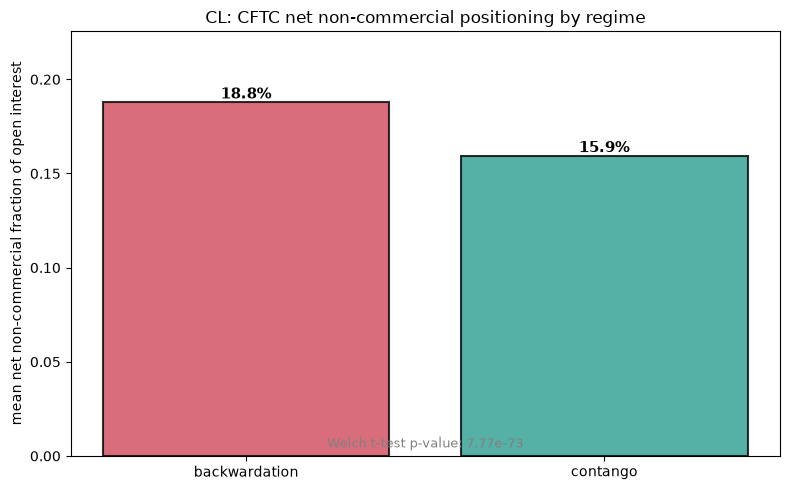

In [15]:
regimes = ["backwardation", "contango"]
fracs = [net_noncomm_means.get(r, 0) for r in regimes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    regimes,
    fracs,
    color=["#d1495b", "#2a9d8f"],
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)

# Annotate values
for bar, frac in zip(bars, fracs):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{frac * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("mean net non-commercial fraction of open interest")
ax.set_ylim(0, max(fracs) * 1.2)
ax.set_title("CL: CFTC net non-commercial positioning by regime")
ax.text(
    0.5,
    0.02,
    f"Welch t-test p-value: {ttest.get('p_value', 'N/A'):.2e}",
    ha="center",
    transform=ax.transAxes,
    fontsize=9,
    color="grey",
)
show(
    fig,
    "Speculators (net non-commercial) hold 18.8% of open interest in backwardation vs 15.9% in contango (p≈8e-73), the sign predicted by Keynes' normal-backwardation theory, though the effect size is modest.",
)

## Phase 5 - Pre-registration for notebook 10b

All decisions and configuration counts are committed here, before any 10b backtest. The gate table
restates NEXT_PROMPT.md sec 4 verbatim. Three regime definitions are computed (raw sign, deadband,
5-day persistence); deadband is declared primary for Gate SPR based on a structural argument (raw
sign is almost always defined, so gating on it barely differs from unconditional trading). ADF-failing
spreads are excluded from 10b's backtest universe — a mechanical decision applied here before any
backtest result was seen. DSR (Deflated Sharpe Ratio) configuration counts are tabulated below.


In [16]:
phase5 = load("phase_5_10a_results.json")
print("Gate table (restated from NEXT_PROMPT.md sec 4, unedited):")
print()
for gate_name, gate_info in phase5["gate_table"].items():
    print(f"Gate {gate_name}:")
    print(f"  Claim: {gate_info['claim']}")
    print(f"  Fires if: {gate_info['fires_if']}")
    print()

Gate table (restated from NEXT_PROMPT.md sec 4, unedited):

Gate SP:
  Claim: unconditional structural mean-reversion in commodity spreads survives cost
  Fires if: net Sharpe > 0 at every origin offset AND block-bootstrap 95% CI on net return (self-financing, baseline zero) excludes zero AND DSR > 0.95 on the cumulative config count

Gate SPR:
  Claim: regime-gating improves it: trading a spread only when its underlying term structure is in a definite contango or backwardation state beats trading it regime-blind
  Fires if: Gate SP's full criterion met by the regime-gated variant AND the regime-gated net Sharpe exceeds the unconditional net Sharpe at every origin offset AND a block-bootstrap 95% CI on the difference (gated minus unconditional) excludes zero

Gate SPR-BW:
  Claim: the operator's specific prior: the effect is not a brent_wti artifact
  Fires if: Gate SPR's improvement holds for brent_wti AND for at least 3 other inter-commodity spreads independently

Gate VS:
  Claim: v

**DSR configuration counts (cumulative and per-gate).**

In [17]:
dsr = phase5["dsr_config_counts"]
print("DSR configuration counts:")
print()
for gate_name in ["SP", "SPR", "SPR-BW", "VS", "BM"]:
    config = dsr.get(gate_name, {})
    n_trials = config.get("n_trials", 0)
    breakdown = config.get("breakdown", "")
    print(f"{gate_name:8s} n_trials={n_trials:2d}  {breakdown}")
print()
print(f"Total n_trials: {dsr.get('total_n_trials', 0)}")
print(f"Total including diagnostics: {dsr.get('total_including_diagnostics', 0)}")

DSR configuration counts:

SP       n_trials= 8  2 taxonomy groups (inter_commodity, calendar) x 4 origin offsets
SPR      n_trials=12  3 regime definitions (raw_sign, deadband, persistent) x 4 origin offsets, inter-commodity group only
SPR-BW   n_trials= 1  the brent_wti both-legs-agree variant, run once (not at every offset -- it is a diagnostic robustness check on SPR's own already-counted per-spread results, not itself a fire-condition search). SPR-BW's per-spread breakdown of Gate SPR's own book contributes 0 additional trials, per the pooling note above.
VS       n_trials= 8  4 already-logged notebook-8 carry configurations (phase_5_results.json's gate_AC n_trials, itself 4 origin offsets on the single 21-day carry horizon) forwarded, not reset to 1, PLUS 4 new vol-scaled-variant configurations (the same 4 origin offsets, re-run under vol-scaled sizing).
BM       n_trials=20  16 already-logged notebook-8 momentum configurations forwarded (the literal n_trials phase_5_results.json

## Bottom line

No strategy verdict belongs here by design — but three findings carry directly into notebook 10b.

**First, cointegration resolves notebook 9's flagged disagreement.** gold_silver and platinum_palladium
fail the ADF test outright (both t < −1.76 vs the 5% critical value −2.86) — they are not actually
cointegrated pairs, consistent with their weak AR(1) and insignificant IC. Both are excluded from 10b's
backtest universe on this pre-declared, mechanical criterion, cutting the inter-commodity universe from
11 to 7 spreads.

**Second, raw-sign gating is structurally insufficient.** Raw sign is defined almost every trading day
(only a slope of exactly zero is null), so gating on it barely differs from unconditional trading and
cannot test the operator's actual claim ("only in a *definite* state"). Deadband — with a 2% annualized
slope threshold, a pre-declared, round convention, not a result-driven choice — is declared primary for
Gate SPR in 10b, with raw sign and persistence as secondary robustness variants.

**Third, brent_wti's regime effect is materially leg-dependent.** Under BZ-only, mean reversion is
nominally *stronger in contango than backwardation*, opposite to the operator's prior. Under both-legs-agree,
the picture flips sharply: 9.5-day half-life in backwardation vs 18.3d in contango, the operator's effect
at full strength on 66.2% of trading days when the legs agree. This tension is unresolved, pre-registered
as Gate SPR-BW's own secondary check for 10b to settle with a real, costed backtest.
